
# Subnormalised-state noise-resilience sweep

This notebook benchmarks the **subnormalised-state preparation workflow** under a one-parameter hardware-noise sweep.

For each sweep point, it reports:
- mean fidelity,
- mean success probability,
- mean Frobenius distance.

To change the sweep, edit the configuration cell and rerun.


In [40]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from algo.dilation_algo import apply_one_ancilla_dilation_to_state, density_matrix_from_state, uniform_superposition
from subnorm.state_preparation import (
    random_subnormalized_state_sample,
    prepare_subnormalized_state_via_method,
)
from noise.noise_simulation import (
    SimpleNISQNoiseParameters,
    apply_default_noise_for_one_ancilla_step,
    apply_amplitude_phase_damping,
    apply_local_depolarizing,
    noisy_single_qubit_measurement,
    apply_assignment_matrix,
    single_qubit_assignment_matrix,
)
from noise.noise_resilience_common import (
    NoiseSweepSpecification,
    linear_sweep,
    log_sweep,
    run_noise_resilience_sweep,
)
from metric.success_probability import (
    success_probability_from_counts,
    method_comparison_success_probability,
)

from plot.noise_sweep_plot import (
    default_sweep_xlabel,
    plot_method_comparison_dataframe,
    SweepPlotColumns,
)

from metric.fidelity_frobenius import evaluate_fidelity_frobenius
from metric.tomography import (
    basis_probabilities,
    expectation_from_counts,
    linear_inversion_density_matrix,
    project_to_physical_density_matrix,
)

## Configuration

In [41]:
# ----------------------
# Sweep configuration
# ----------------------
noise_kind = 'readout'  # 'amplitude_damping', 'phase_damping', 'depolarizing', 'readout'
parameterization = 'probability'  # 'probability' for all; 'rate' also works for amplitude/phase damping
sweep_values = linear_sweep(0.0, 0.20, 9)
# sweep_values = log_sweep(1e-3, 2e-1, 8)  # alternative

# ----------------------
# Methods to compare
# ----------------------
methods = ['paper_svd', 'sz_nagy', 'unitary_rescaled']

# For the unitary-only baseline:
# - False -> plot a flat success-probability line at 1.0
# - True  -> store success probability as NaN
unitary_baseline_as_nan = False
unitary_baseline_success_value = 1.0

# ----------------------
# Experiment size
# ----------------------
num_states = 48
repeats = 3
shots_ancilla = 4000
shots_tomography = 4000
rng_seed = 20260415

# ----------------------
# Noise-model baseline
# ----------------------
base_noise_params = SimpleNISQNoiseParameters(
    t1_system=np.inf,
    t2_system=np.inf,
    t1_ancilla=np.inf,
    t2_ancilla=np.inf,
    one_qubit_gate_time=1.0,
    two_qubit_gate_time=1.0,
    p1q_depolarizing=0.0,
    p2q_depolarizing=0.0,
    readout_p0_to_1_system=0.0,
    readout_p1_to_0_system=0.0,
    readout_p0_to_1_ancilla=0.0,
    readout_p1_to_0_ancilla=0.0,
)

# ----------------------
# Sweep-spec options
# ----------------------
spec = NoiseSweepSpecification(
    noise_kind=noise_kind,
    sweep_values=sweep_values,
    parameterization=parameterization,
    duration=base_noise_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='both',
    depolarizing_mode='both',
    symmetric_readout=True,
)

print('Sweep points:', len(sweep_values))
print('Methods:', methods)

Sweep points: 9
Methods: ['paper_svd', 'sz_nagy', 'unitary_rescaled']


## Helper functions used only in this notebook

In [42]:
def ancilla_zero_block(two_qubit_density_matrix: np.ndarray) -> np.ndarray:
    # Return the ancilla-|0> block for ancilla-first ordering.
    rho = np.asarray(two_qubit_density_matrix, dtype=complex)
    if rho.shape != (4, 4):
        raise ValueError('Expected a 4x4 two-qubit density matrix.')
    return rho[:2, :2]


def conditional_system_state_given_ancilla_zero(two_qubit_density_matrix: np.ndarray, tol: float = 1e-12):
    # Return (p_success, rho_system|anc=0) from a noisy 2-qubit density matrix.
    block = ancilla_zero_block(two_qubit_density_matrix)
    p_success = float(np.real(np.trace(block)))
    if p_success <= tol:
        return 0.0, None
    return p_success, block / p_success


def sample_binary_counts(probabilities, shots: int, rng: np.random.Generator):
    probs = np.asarray(probabilities, dtype=float).reshape(2)
    probs = np.maximum(probs, 0.0)
    probs = probs / np.sum(probs)
    samples = rng.multinomial(int(shots), probs)
    return {'0': int(samples[0]), '1': int(samples[1])}


def perform_single_qubit_tomography_with_readout_error(
    rho: np.ndarray,
    *,
    shots: int,
    p0_to_1: float,
    p1_to_0: float,
    rng: np.random.Generator,
) -> np.ndarray:
    # One-qubit tomography with classical readout error on the system qubit.
    measured_expectations = {}
    amat = single_qubit_assignment_matrix(p0_to_1, p1_to_0)

    for basis in ('X', 'Y', 'Z'):
        probs = basis_probabilities(rho, basis)
        true_probs = np.array([probs['0'], probs['1']], dtype=float)
        observed_probs = apply_assignment_matrix(true_probs, amat)
        counts = sample_binary_counts(observed_probs, shots=shots, rng=rng)
        measured_expectations[basis] = expectation_from_counts(counts)

    target_trace = float(np.real(np.trace(rho)))
    reconstructed = linear_inversion_density_matrix(measured_expectations, trace=target_trace)
    physical = project_to_physical_density_matrix(reconstructed)
    physical = physical * target_trace
    return physical


def apply_noise_to_single_qubit_baseline(
    rho_one_qubit: np.ndarray,
    noise_params: SimpleNISQNoiseParameters,
) -> np.ndarray:
    """
    Apply the same first-tier hardware-noise model to the unitary-only baseline,
    but only on the system qubit (no ancilla, no 2-qubit depolarizing layer).
    """
    rho = np.asarray(rho_one_qubit, dtype=complex)

    rho = apply_amplitude_phase_damping(
        rho,
        target=0,
        num_qubits=1,
        duration=noise_params.one_qubit_gate_time,
        t1=noise_params.t1_system,
        t2=noise_params.t2_system,
        renormalize=False,
    )

    if noise_params.p1q_depolarizing > 0.0:
        rho = apply_local_depolarizing(
            rho,
            target=0,
            num_qubits=1,
            probability=noise_params.p1q_depolarizing,
            renormalize=False,
        )

    return np.asarray(rho, dtype=complex)


def run_subnorm_noise_case(
    noise_params,
    sweep_value,
    repeat_index,
    rng,
    *,
    num_states,
    shots_ancilla,
    shots_tomography,
    method,
    unitary_baseline_as_nan,
    unitary_baseline_success_value,
):
    fidelities = []
    frobenius_distances = []
    success_probabilities = []
    exact_success_probabilities = []

    for _ in range(int(num_states)):
        sample = random_subnormalized_state_sample(rng=rng, simulate_dilation=False)

        prep = prepare_subnormalized_state_via_method(
            sample.target_subnormalized_state,
            method=method,
            auto_scale=False,
        )

        # ------------------------------------------------------------
        # Unitary-only rescaled baseline
        # ------------------------------------------------------------
        if prep.method == 'unitary_rescaled':
            rho_system_ideal = density_matrix_from_state(prep.normalized_success_state)
            rho_system_noisy = apply_noise_to_single_qubit_baseline(rho_system_ideal, noise_params)

            rho_tomo = perform_single_qubit_tomography_with_readout_error(
                rho_system_noisy,
                shots=int(shots_tomography),
                p0_to_1=noise_params.readout_p0_to_1_system,
                p1_to_0=noise_params.readout_p1_to_0_system,
                rng=rng,
            )

            rho_recovered = sample.state_trace * rho_tomo

            p_success_raw = method_comparison_success_probability(
                prep.method,
                unitary_baseline_value=unitary_baseline_success_value,
                unitary_baseline_as_nan=unitary_baseline_as_nan,
            )
            p_success_exact = method_comparison_success_probability(
                prep.method,
                unitary_baseline_value=unitary_baseline_success_value,
                unitary_baseline_as_nan=unitary_baseline_as_nan,
            )

            metrics = evaluate_fidelity_frobenius(sample.exact_density_matrix, rho_recovered)
            fidelities.append(metrics.fidelity)
            frobenius_distances.append(metrics.frobenius_distance)
            success_probabilities.append(p_success_raw)
            exact_success_probabilities.append(p_success_exact)
            continue

        # ------------------------------------------------------------
        # Postselected methods: paper SVD and Sz.-Nagy
        # ------------------------------------------------------------
        rho_two_qubit_ideal = density_matrix_from_state(prep.backend_result.ancilla_system_output)
        rho_two_qubit_noisy = apply_default_noise_for_one_ancilla_step(rho_two_qubit_ideal, noise_params)
        rho_two_qubit_noisy = np.asarray(rho_two_qubit_noisy, dtype=complex)

        p_success_exact_local, rho_conditional = conditional_system_state_given_ancilla_zero(rho_two_qubit_noisy)
        p_success_exact = method_comparison_success_probability(
            prep.method,
            raw_success_probability=p_success_exact_local,
        )
        exact_success_probabilities.append(p_success_exact)

        if rho_conditional is None:
            p_success_raw = method_comparison_success_probability(
                prep.method,
                raw_success_probability=0.0,
            )
            success_probabilities.append(p_success_raw)
            fidelities.append(0.0)
            frobenius_distances.append(float(np.linalg.norm(sample.exact_density_matrix, ord='fro')))
            continue

        ancilla_measurement = noisy_single_qubit_measurement(
            [p_success_exact_local, 1.0 - p_success_exact_local],
            p0_to_1=noise_params.readout_p0_to_1_ancilla,
            p1_to_0=noise_params.readout_p1_to_0_ancilla,
            shots=int(shots_ancilla),
            rng=rng,
        )
        p_success_raw_local = success_probability_from_counts(
            ancilla_measurement.counts,
            success_key='0',
        ).success_probability

        p_success_raw = method_comparison_success_probability(
            prep.method,
            raw_success_probability=p_success_raw_local,
        )
        success_probabilities.append(p_success_raw)

        rho_tomo = perform_single_qubit_tomography_with_readout_error(
            rho_conditional,
            shots=int(shots_tomography),
            p0_to_1=noise_params.readout_p0_to_1_system,
            p1_to_0=noise_params.readout_p1_to_0_system,
            rng=rng,
        )

        rho_recovered = 2.0 * p_success_raw_local * rho_tomo

        metrics = evaluate_fidelity_frobenius(sample.exact_density_matrix, rho_recovered)
        fidelities.append(metrics.fidelity)
        frobenius_distances.append(metrics.frobenius_distance)

    return {
        'method': str(method),
        'fidelity': float(np.nanmean(fidelities)),
        'frobenius_distance': float(np.nanmean(frobenius_distances)),
        'success_probability': float(np.nanmean(success_probabilities)),
        'success_probability_exact': float(np.nanmean(exact_success_probabilities)),
        'num_states': int(num_states),
        'shots_ancilla': int(shots_ancilla),
        'shots_tomography': int(shots_tomography),
        'sweep_value_echo': float(sweep_value),
        'repeat_echo': int(repeat_index),
    }

## Single-point smoke test

In [43]:
rng = np.random.default_rng(rng_seed)

smoke_rows = []
for method in methods:
    smoke = run_subnorm_noise_case(
        base_noise_params,
        sweep_value=0.0,
        repeat_index=0,
        rng=rng,
        num_states=6,
        shots_ancilla=1000,
        shots_tomography=1000,
        method=method,
        unitary_baseline_as_nan=unitary_baseline_as_nan,
        unitary_baseline_success_value=unitary_baseline_success_value,
    )
    smoke_rows.append(smoke)

pd.DataFrame(smoke_rows)

,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_states,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,paper_svd,0.996911,0.036908,0.320167,0.315864,6,1000,1000,0.0,0
1,sz_nagy,0.995744,0.017133,0.305333,0.308633,6,1000,1000,0.0,0
2,unitary_rescaled,0.995474,0.011042,1.000000,1.000000,6,1000,1000,0.0,0


## Run the full resilience sweep

In [44]:
all_raw_results = []
all_summary_results = []

for method in methods:
    sweep_result = run_noise_resilience_sweep(
        run_subnorm_noise_case,
        base_params=base_noise_params,
        specification=spec,
        repeats=repeats,
        rng_seed=rng_seed,
        runner_kwargs={
            'num_states': num_states,
            'shots_ancilla': shots_ancilla,
            'shots_tomography': shots_tomography,
            'method': method,
            'unitary_baseline_as_nan': unitary_baseline_as_nan,
            'unitary_baseline_success_value': unitary_baseline_success_value,
        },
    )

    raw_df = sweep_result.raw_results.copy()
    summary_df = sweep_result.summary_results.copy()

    raw_df['method'] = method
    summary_df['method'] = method

    all_raw_results.append(raw_df)
    all_summary_results.append(summary_df)

raw_results = pd.concat(all_raw_results, ignore_index=True)
summary_results = pd.concat(all_summary_results, ignore_index=True)

print('Raw results shape:', raw_results.shape)
print('Summary results shape:', summary_results.shape)
summary_results.head(12)

Raw results shape: (81, 15)
Summary results shape: (27, 22)


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,frobenius_distance_mean,frobenius_distance_std,success_probability_mean,success_probability_std,success_probability_exact_mean,...,num_states_std,shots_ancilla_mean,shots_ancilla_std,shots_tomography_mean,shots_tomography_std,sweep_value_echo_mean,sweep_value_echo_std,repeat_echo_mean,repeat_echo_std,method
0,readout,probability,0.000,0.998171,0.000310,0.012685,0.001789,0.254161,0.028348,0.254512,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,paper_svd
1,readout,probability,0.025,0.974857,0.000697,0.027759,0.001253,0.262948,0.019245,0.250249,...,0.0,4000.0,0.0,4000.0,0.0,0.025,0.0,1.0,1.0,paper_svd
2,readout,probability,0.050,0.950425,0.000654,0.049444,0.002145,0.265233,0.002196,0.239320,...,0.0,4000.0,0.0,4000.0,0.0,0.050,0.0,1.0,1.0,paper_svd
3,readout,probability,0.075,0.925220,0.000543,0.070566,0.002707,0.288965,0.010626,0.252290,...,0.0,4000.0,0.0,4000.0,0.0,0.075,0.0,1.0,1.0,paper_svd
4,readout,probability,0.100,0.899935,0.000633,0.096142,0.002116,0.289167,0.014627,0.236106,...,0.0,4000.0,0.0,4000.0,0.0,0.100,0.0,1.0,1.0,paper_svd
5,readout,probability,0.125,0.874257,0.001339,0.116601,0.002407,0.312606,0.010281,0.250504,...,0.0,4000.0,0.0,4000.0,0.0,0.125,0.0,1.0,1.0,paper_svd
6,readout,probability,0.150,0.850444,0.000049,0.138301,0.001157,0.339444,0.006802,0.269929,...,0.0,4000.0,0.0,4000.0,0.0,0.150,0.0,1.0,1.0,paper_svd
7,readout,probability,0.175,0.825408,0.000780,0.165285,0.008852,0.330054,0.006987,0.238701,...,0.0,4000.0,0.0,4000.0,0.0,0.175,0.0,1.0,1.0,paper_svd
8,readout,probability,0.200,0.799878,0.001103,0.194069,0.017055,0.345399,0.011868,0.242914,...,0.0,4000.0,0.0,4000.0,0.0,0.200,0.0,1.0,1.0,paper_svd
9,readout,probability,0.000,0.998171,0.000310,0.012685,0.001789,0.254161,0.028348,0.254512,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,sz_nagy


## Inspect raw repeated-run records

In [45]:
raw_results.head(18)

,noise_kind,parameterization,sweep_index,sweep_value,repeat_index,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_states,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,readout,probability,0,0.000,0,paper_svd,0.998094,0.013464,0.257375,0.258388,48,4000,4000,0.000,0
1,readout,probability,0,0.000,1,paper_svd,0.997907,0.013951,0.280766,0.280835,48,4000,4000,0.000,1
2,readout,probability,0,0.000,2,paper_svd,0.998512,0.010638,0.224344,0.224312,48,4000,4000,0.000,2
3,readout,probability,1,0.025,0,paper_svd,0.975401,0.027532,0.256609,0.242294,48,4000,4000,0.025,0
4,readout,probability,1,0.025,1,paper_svd,0.975098,0.026636,0.284562,0.274240,48,4000,4000,0.025,1
5,readout,probability,1,0.025,2,paper_svd,0.974071,0.029110,0.247672,0.234211,48,4000,4000,0.025,2
6,readout,probability,2,0.050,0,paper_svd,0.951180,0.048006,0.267531,0.240864,48,4000,4000,0.050,0
7,readout,probability,2,0.050,1,paper_svd,0.950048,0.048416,0.263156,0.237002,48,4000,4000,0.050,1
8,readout,probability,2,0.050,2,paper_svd,0.950046,0.051910,0.265010,0.240093,48,4000,4000,0.050,2
9,readout,probability,3,0.075,0,paper_svd,0.925706,0.073612,0.293974,0.258346,48,4000,4000,0.075,0


## Plot fidelity and success probability against the swept parameter

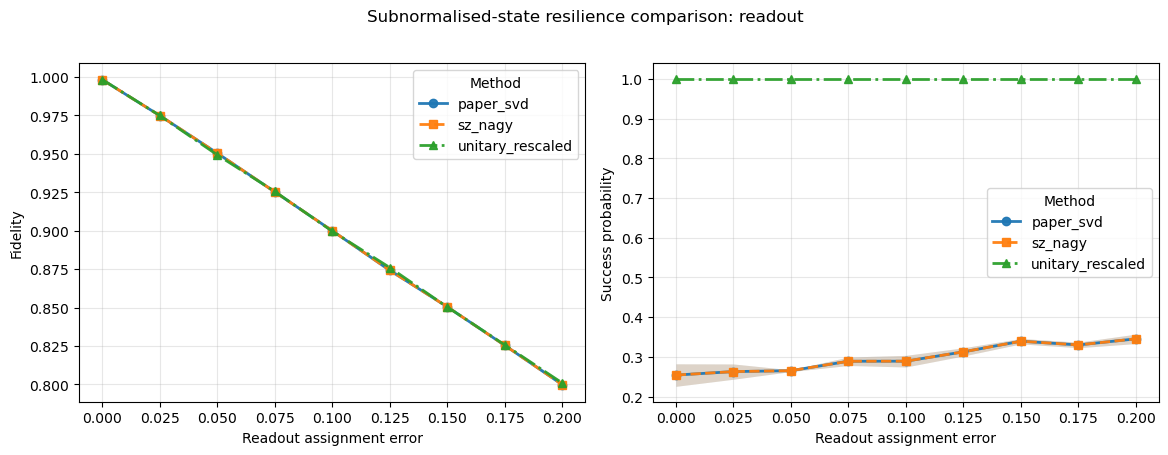

In [46]:
method_line_styles = {
    'paper_svd': '-',
    'sz_nagy': '--',
    'unitary_rescaled': '-.',
}

fig, axs = plot_method_comparison_dataframe(
    summary_results,
    method_column='method',
    columns=SweepPlotColumns(
        sweep_value='sweep_value',
        fidelity_mean='fidelity_mean',
        fidelity_std='fidelity_std',
        success_mean='success_probability_mean',
        success_std='success_probability_std',
    ),
    xlabel=default_sweep_xlabel(noise_kind),
    title=f'Subnormalised-state resilience comparison: {noise_kind}',
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    markers=['o', 's', '^'],
    line_styles=method_line_styles,
    legend_title='Method',
)
plt.show()

## Saves the figure

In [47]:
out_dir = Path.cwd()
fig.savefig(out_dir / 'subnorm_readout_resilience.pdf', dpi=200, bbox_inches='tight')
plt.close(fig)